# Introduction to Numerical Python


NumPy is the fundamental package for scientific computing in Python. It is a Python library that provides a multidimensional array object, various derived objects (such as masked arrays and matrices), and an assortment of routines for fast operations on arrays, including mathematical, logical, shape manipulation, sorting, selecting, I/O, discrete Fourier transforms, basic linear algebra, basic statistical operations, random simulation and much more.

Numpy Wedsite: https://numpy.org

## Arrays 

Recall that, in standard Python, we can create a list containing arbitrary objects, each of which may be stored in disparate parts of the computer's memory. For example: 

In [1]:
L = [1,'picard',20,3.0]
for item in L:
    print(item)

1
picard
20
3.0


Because these items occupy different memory locations, operations that take place directly on lists typically require allocating memory many times. 

On the other hand, arrays as defined via `numpy` occupy a single, contiguous chunk of memory. This allows `numpy` arrays to occupy significantly less memory, and makes operations involving `numpy` arrays correspondingly faster. This performance improvement is usually only realized for arrays that contain a single data type. For more details on this, see the accompanying [reading](https://jakevdp.github.io/PythonDataScienceHandbook/02.01-understanding-data-types.html) for this lecture.  

Arrays are ideally suited for operating on large chunks of numbers or text. Let's look at a simple example to see how `numpy` arrays can dramatically improve the performance of our code. The `%timeit` decorator is a "magic" command that will run the supplied line of code many times and print out some measurse of how quickly the code executed. 

In [2]:
def add_list(L1,L2):
    return[L1[i] +L2[i] for i in range(len(L1))]

In [3]:
L1 = list(range(1000))
L2 = list(range(1000))

In [4]:
L = add_list(L1,L2)
print(type(L), len(L))
%timeit add_list(L1,L2)

<class 'list'> 1000
43 μs ± 1.41 μs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


Now let's try this with `numpy` arrays. An especially useful way to create an array is to call `np.array()` on a list. 

In [5]:
import numpy as np
a1 = np.array(L1)
a2 = np.array(L2)
print(type(a1),type(a2))
%timeit a1+a2

<class 'numpy.ndarray'> <class 'numpy.ndarray'>
744 ns ± 4.91 ns per loop (mean ± std. dev. of 7 runs, 1,000,000 loops each)


In [7]:
list_1 = [1,2,3]
list_2 = [4,5,6]
arr_1 = np.array(list_1)
arr_2 = np.array(list_2)
print(arr_1+arr_2)                      # using + operator on arrays of same size adds each element to 

[5 7 9]


The same operation (entrywise addition) is much faster when using `numpy` arrays! 

Arrays can also contain strings. This is not very common, and in most cases the arrays we write in this class will contain integers or floats. 

In [8]:
s = 'hello world'
np.array(s.split())

array(['hello', 'world'], dtype='<U5')

## Vectorization

You might have noticed that, in the code above, we were able to do `a1 + a2` and get the expected result. As you may have seen already, this doesn't exactly work for lists: `L1 + L2` concatenates the lists, rather than computing the entrywise sum. 

A *vectorized* function is one that operates on all elements of an array in entrywise fashion. So, we saw above that the `+` function, when applied to arrays, is vectorized. The `numpy` module includes a large number of vectorized functions. These should almost always be used when working with arrays: 

In [10]:
# entrywise array multiplication
a1 = np.array([1,2,3,4,5])
a2 = np.array([2,3,4,5,4])
print(a1+a2)
print(a1-a2)
print(a1 *a2)
print(a1/a2)

[3 5 7 9 9]
[-1 -1 -1 -1  1]
[ 2  6 12 20 20]
[0.5        0.66666667 0.75       0.8        1.25      ]


In [12]:
a1 = np.array([1,2,3])
print(a1 / 2)

[0.5 1.  1.5]


In [13]:
# entrywise scalar multiplication
print(2*a1)

[2 4 6]


In [14]:
# scalar addition 
print(a1+2)

[3 4 5]


Vectorized functions operating on `numpy` arrays can be vastly more efficient than approaches that operate on lists one-by-one. We already saw the example of vectorized addition. Here's another one: 

In [16]:
import math
def list_sin(L):
    return [math.sin(x) for x in L]

In [17]:
a = np.linspace(0,2*np.pi, 101)
L = list(a)
sin_L = list_sin(L)
%timeit list_sin(L)

5.44 μs ± 250 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)


In [18]:
# faster and way easier to write! 
%timeit np.sin(a)

931 ns ± 13.2 ns per loop (mean ± std. dev. of 7 runs, 1,000,000 loops each)


Let's check that this works: 

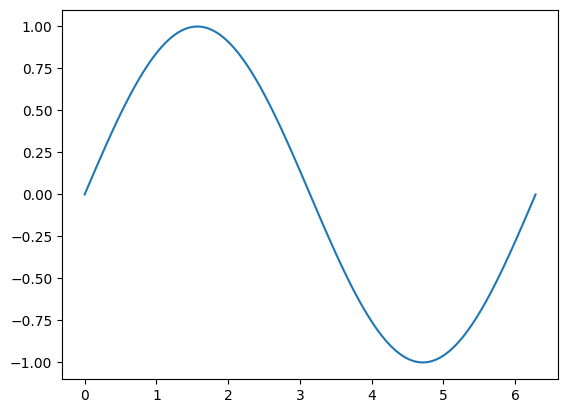

In [19]:
from matplotlib import pyplot as plt
plt.plot(L, sin_L)

Our `for`-loop based approach works, but....

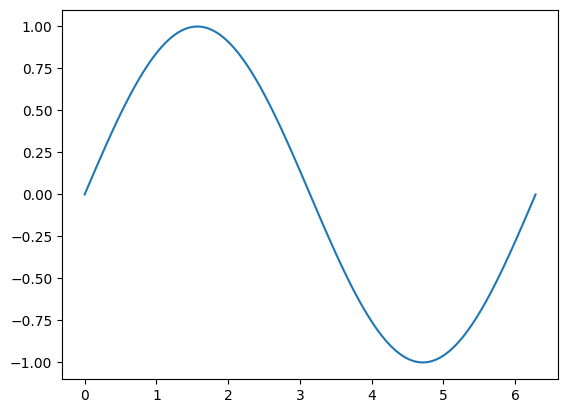

In [20]:
# works as a one-liner
plt.plot(a,np.sin(a))

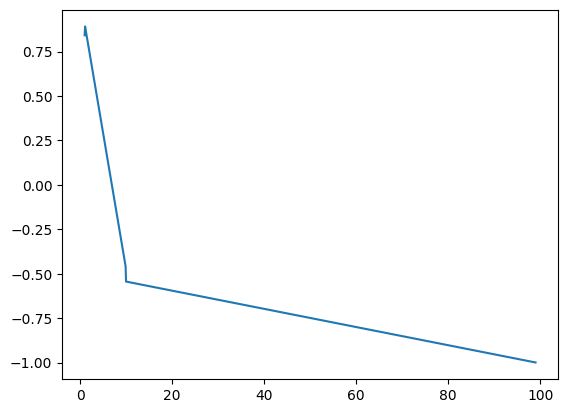

In [22]:
a = np.array([1,1.1,9.9,10,99])
plt.plot(a, np.sin(a))

# **Syntax to make numpy array is = np.array("some list")**

## "Should I use `numpy` arrays?"

If you will operate on one or more large sets of numbers and are considering writing `for`-loops, stop. Ask yourself whether you can achieve your task with `numpy` arrays instead. 90% of the time, `numpy`-based code is faster to write and faster to execute. 

## "Should I use `for`-loops?"

When working with lists and other basic data structures, yes, absolutely! When working with `numpy` arrays, however, writing `for`-loops is almost always the wrong thing to do. Find a way using vectorized `numpy` code. 

## Creating Arrays

The simplest way to create small, custom arrays in `numpy` is by transforming a list into an array. 

In [23]:
L = [1,2,3,4]
a = np.array(L)
print(type(L), type(a))

<class 'list'> <class 'numpy.ndarray'>


`numpy` also offers functions for building a number of common arrays. 

In [ ]:
np.zeros(5)

In [ ]:
np.ones(6)

In [ ]:
# random numbers between 0 and 1
np.random.rand(5)

In [ ]:
# an array version of range()
print(type(range(5)), range(5))
print(np.arange(5),type(np.arange(5)))

In [ ]:
# 3 evenly-spaced points between 0  and 1, inclusive
print(np.linspace(0,1,3), type(np.linspace(0,1,3)))

In [ ]:
print(np.zeros(5))                      # array of zeros of given len 
print(np.ones(3))                       # array of ones of given len 
print(np.random.rand(2))                # array with random num of given len            np.random.rand(2)

[0. 0. 0. 0. 0.]
[1. 1. 1.]
[0.63105649 0.10069627]


## Multidimensional Arrays

`numpy` arrays have **dimensions** (or **axes**). So far, we've only worked with one-dimensional arrays. A good way to check the dimensions of an array is with the `shape` attribute: 

In [27]:
a = np.ones(5)
print(a.shape)


b = np.random.rand(100)
print(b.shape)

(5,)
(100,)


This says that `a` has a single dimension, and has three entries along that dimension. Here's a 2d array: 

In [37]:
A = np.ones([5,5])
print(A.shape)                  # given in (row, col)

# multidimensional array! 
B = np.zeros((2,2))
print(B)

(5, 5)
[[0. 0.]
 [0. 0.]]


Now, `A` has two dimensions, and has three entries along each dimension. For 2-dimensional arrays, `numpy` will helpfully print out the array in format that makes the dimensions clear. 

In [32]:
A

array([[1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1.]])

You can create arrays of arbitrary numbers of dimensions.

In [36]:
B = np.ones((3,3,3))
B.shape
print(B)


C = np.zeros([3,3,3])
print(C.shape)
print(C)

[[[1. 1. 1.]
  [1. 1. 1.]
  [1. 1. 1.]]

 [[1. 1. 1.]
  [1. 1. 1.]
  [1. 1. 1.]]

 [[1. 1. 1.]
  [1. 1. 1.]
  [1. 1. 1.]]]
(3, 3, 3)
[[[0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]]

 [[0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]]

 [[0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]]]


In [ ]:
B

The `reshape` method allows you to alter the dimensions of an array. For example, let's initialize a 1d array and transform it into a 2d array. 

In [38]:
a = np.arange(15)
print(a)

[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14]


In [39]:
A = a.reshape(3,5)
A

array([[ 0,  1,  2,  3,  4],
       [ 5,  6,  7,  8,  9],
       [10, 11, 12, 13, 14]])

We can also undo this operation: 

In [40]:
a = A.reshape(15)
a

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14])

In [42]:
A = np.ones((2,2))
A

array([[1., 1.],
       [1., 1.]])

In [43]:
A.reshape(4)

array([1., 1., 1., 1.])

In [52]:
C = np.arange(2,10)
print(C, len(C))
C_1 = C.reshape(8,1)
print(C_1)

[2 3 4 5 6 7 8 9] 8
[[2]
 [3]
 [4]
 [5]
 [6]
 [7]
 [8]
 [9]]


## Accessing Array Elements

Often, we want to access the data contained inside an array, for the purpose of either modifying the data or using it in later computation. For 1d arrays, the simplest way to do this is very similar to how we would do so for a list: 

In [53]:
a = np.arange(1,11)
a

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10])

In [ ]:
# zero indexing
print(a[0])

In [ ]:
print(a[-1])

In [ ]:
# slicing
print(a[:4])

# **Indexing numpy array is pretty straightforward**

In [54]:
hi = np.arange(1,11)
print(hi)
print(hi[-1])

[ 1  2  3  4  5  6  7  8  9 10]
10


In [55]:
# 'fancy' indexing
# passing a list lets you single out individual values
print(a[3], a[7], a[9])
print(a[[3,7,9]], type(a[[3,7,9]]))
print(a[[3,9,7]], type(a[[3,9,7]]))

4 8 10
[ 4  8 10] <class 'numpy.ndarray'>
[ 4 10  8] <class 'numpy.ndarray'>


An extremely useful technique is boolean indexing. The important points about boolean indexing is that boolean comparisons in `numpy` are vectorized, and generate arrays of boolean values. 

In [60]:
# boolean indexing
# passing an array of True/False lets you grab elements according to a criterion
print(a > 5, type(a>5))                 # gives you a True/False array
print(a[a>5])                           # gives you actual indices of where it happens!

[False False False False False  True  True  True  True  True] <class 'numpy.ndarray'>
[ 6  7  8  9 10]


In [61]:
some_arr = np.arange(1,6)
print(some_arr > 3)
print(some_arr[some_arr > 3])

[False False False  True  True]
[4 5]
